<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/26_feature_engineering_feature_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering and Feature Selection

In this notebook, we create engineered features and use feature selection techniques to improve Machine Learning model performance.

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import make_classification
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

from sklearn.linear_model import LogisticRegression

In [2]:
X, y = make_classification(
    n_samples=200,
    n_features=10,
    n_informative=3,
    n_redundant=2,
    n_repeated=0,
    random_state=42
)

In [3]:
columns = [
    f"Feature_{i}"
    for i in range(X.shape[1])
]

df = pd.DataFrame(
    X,
    columns=columns
)

df.head()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9
0,0.243339,0.235276,-1.251539,0.174415,-0.241236,0.352055,0.668446,0.227214,1.443765,-0.775033
1,-1.119617,2.536635,0.323168,1.765551,0.140886,-1.768439,1.530457,-1.009503,-0.147603,-2.709000
2,-0.753418,-0.159656,2.013387,-1.426231,0.459972,-0.677715,2.171264,1.196960,0.136535,-1.810434
3,-0.784898,0.632096,0.419532,0.463180,0.648280,-0.120948,1.596430,0.488656,-0.887492,-1.883543
4,-0.466037,1.129796,-0.532701,-1.390731,-1.594703,0.513600,3.531827,0.879315,-1.169917,-3.590575


Train Model Using ALL Features

In [4]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(X, y)

full_score = model.score(X, y)

print(
    "Accuracy using all features:",
    full_score
)

Accuracy using all features: 0.925


In [5]:
selector = SelectKBest(
    score_func=f_classif,
    k=3
)

X_selected = selector.fit_transform(X, y)

In [6]:
selected_mask = selector.get_support()

selected_features = np.array(columns)[selected_mask]

print(
    "Selected Features:"
)

print(selected_features)

Selected Features:
['Feature_1' 'Feature_3' 'Feature_9']


Train Model Using Selected Features

In [8]:
model_selected = LogisticRegression(
    max_iter=1000
)

model_selected.fit(X_selected, y)

selected_score = model_selected.score(
    X_selected,
    y
)

print(
    "Accuracy using selected features:",
    selected_score
)

Accuracy using selected features: 0.92


In [9]:
comparison = pd.DataFrame({
    "Approach": [
        "All Features",
        "Selected Features"
    ],
    "Accuracy": [
        full_score,
        selected_score
    ]
})

comparison

,Approach,Accuracy
0,All Features,0.925
1,Selected Features,0.920


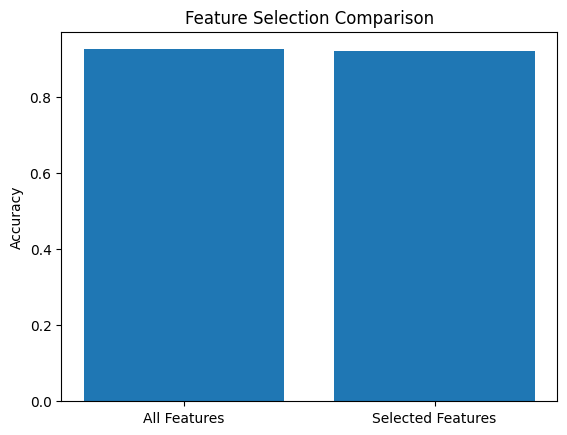

In [10]:
import matplotlib.pyplot as plt

plt.bar(
    comparison["Approach"],
    comparison["Accuracy"]
)

plt.ylabel("Accuracy")

plt.title("Feature Selection Comparison")

plt.show()